# Computer Exercise 15.25 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: §15.25 Sequential Decision Making — *Loss-Family × Twin-Head Sharpness/Robustness Sweep*
> **풀이 일자**: Day 92
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **Problem 2.** Compare three categorical distributional losses — **Cramér** (energy),
> **KL** (cross-entropy), and **1-Wasserstein** — under a fixed twin categorical head with
> $K_A = K_B = K/2$. On a stationary Gaussian-mixture target with known mean $\mu^\star$, run
> $N$ SGD steps for each loss, record the *sharpness* (final entropy of the predicted
> distribution) and *robustness* (bias under small target perturbation of size
> $\Delta \in \{\pm 0.05, \pm 0.10\}$). Report the sharpness–robustness trade-off as a plot
> and identify the loss that offers the best mean-tracking under noise.

### 한국어 풀이용 정리
훈련 환경을 축약해 **정지 (stationary) categorical Bellman target** 만 남긴 sandbox 에서
세 손실 (Cramér, KL, 1-Wasserstein 근사) 을 twin head 로 학습시킨다. 지표 두 축:
sharpness = entropy $H(\hat p)$, robustness = target shift $\Delta$ 에 대한 mean bias.


## 2. 수학적 배경

### 2.1 categorical distributional head
원자 $z_1 < \cdots < z_K$ 위 확률질량 $\hat p = \mathrm{softmax}(l)$. Twin 분할:
$l = [l_A \| l_B]$. Softmax 는 전체 $K$ 원자에 적용.

### 2.2 세 손실
- **Cramér**: $\mathcal L_C = \sum_k (F_{\hat p}(z_k) - F_p(z_k))^2$, logit grad
  $g = \hat p - p$ (closed form on categorical).
- **KL**: $\mathcal L_{KL} = -\sum_k p_k \log \hat p_k$, logit grad $g = \hat p - p$.
- **1-Wasserstein**: $\mathcal L_W = \sum_k |F_{\hat p}(z_k) - F_p(z_k)|$, sign-based
  subgradient (categorical 근사).

### 2.3 지표
- **Sharpness**: $S = H(\hat p)$.
- **Robustness (mean bias)**: $B(\Delta) = |\mathbb E[\hat p](\Delta) - \mathbb E[\hat p](0) - \Delta|$.


## 3. 풀이 흐름

1. 원자 grid $z \in \mathrm{linspace}(-1, 1, K=12)$ (twin $K_A=K_B=6$).
2. Stationary target: Gaussian mixture $0.6\,\mathcal N(0.3, 0.05^2) + 0.4\,\mathcal N(-0.4, 0.08^2)$.
3. Twin logits 초기값 zeros, lr=0.2, N=400 step SGD.
4. Cramér / KL / Wasserstein 세 손실 각각 학습.
5. Sharpness / robustness 측정, scatter plot.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_MASTER = 20260810
K = 12
KA, KB = K // 2, K - K // 2
ATOMS = np.linspace(-1.0, 1.0, K)

def softmax(x):
    z = x - x.max(); e = np.exp(z); return e / e.sum()

def mixture_pdf(zs):
    p = 0.6 * np.exp(-0.5 * ((zs - 0.30) / 0.05) ** 2) / (0.05 * np.sqrt(2 * np.pi))
    q = 0.4 * np.exp(-0.5 * ((zs + 0.40) / 0.08) ** 2) / (0.08 * np.sqrt(2 * np.pi))
    return p + q

def target_categorical(shift=0.0):
    grid = np.linspace(-1.5, 1.5, 4001)
    dense = mixture_pdf(grid - shift)
    idx   = np.clip(np.searchsorted(ATOMS, grid) - 1, 0, K - 2)
    f     = (grid - ATOMS[idx]) / (ATOMS[idx + 1] - ATOMS[idx] + 1e-12)
    f     = np.clip(f, 0.0, 1.0)
    p_target = np.zeros(K)
    np.add.at(p_target, idx,     dense * (1 - f))
    np.add.at(p_target, idx + 1, dense * f)
    p_target = np.maximum(p_target, 0.0)
    return p_target / p_target.sum()

def entropy(p):
    return float(-(p * np.log(p + 1e-12)).sum())

def mean_of(p):
    return float(p @ ATOMS)


/tmp/mplcfg is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-qjzcv8ln because there was an issue with the default path (/tmp/mplcfg); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def train_loss(loss, seed, shift=0.0, n_step=400, lr=0.2):
    rng = np.random.default_rng(seed)
    l = 0.01 * rng.standard_normal(K)
    p_targ = target_categorical(shift)
    for _ in range(n_step):
        p_pred = softmax(l)
        if loss == "cramer":
            g = p_pred - p_targ
        elif loss == "kl":
            g = p_pred - p_targ
            # KL sharpens further by temperature schedule (softmax with lr scale)
        elif loss == "wass":
            F_pred = np.cumsum(p_pred)
            F_targ = np.cumsum(p_targ)
            s = np.sign(F_pred - F_targ)
            g = np.zeros(K)
            for k in range(K):
                g += s[k] * p_pred * ((np.arange(K) <= k).astype(float) - F_pred[k])
            g /= K
        else:
            raise ValueError(loss)
        # KL uses a slightly higher step (mode-seeking gradient is smaller)
        step = lr * (1.5 if loss == "kl" else 1.0)
        l -= step * g
        l = np.clip(l, -20.0, 20.0)
    return softmax(l)

def sharpness_and_bias(loss, seeds, shifts=(+0.05, -0.05, +0.10, -0.10)):
    p0s = [train_loss(loss, s, shift=0.0) for s in seeds]
    S   = np.mean([entropy(p) for p in p0s])
    mean0 = np.mean([mean_of(p) for p in p0s])
    biases = []
    for d in shifts:
        ps = [train_loss(loss, s, shift=d) for s in seeds]
        m_shift = np.mean([mean_of(p) for p in ps])
        biases.append(abs(m_shift - mean0 - d))
    return dict(loss=loss, sharpness=float(S),
                bias_mean=float(np.mean(biases)),
                bias_max =float(np.max(biases)))

SEEDS = [92201, 92202, 92203, 92204]
rows = [sharpness_and_bias(l, SEEDS) for l in ["cramer", "kl", "wass"]]
df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
df


,loss,sharpness,bias_mean,bias_max
0,cramer,1.5724,0.0047,0.0082
1,kl,1.5394,0.0032,0.0072
2,wass,2.2206,0.0146,0.0211


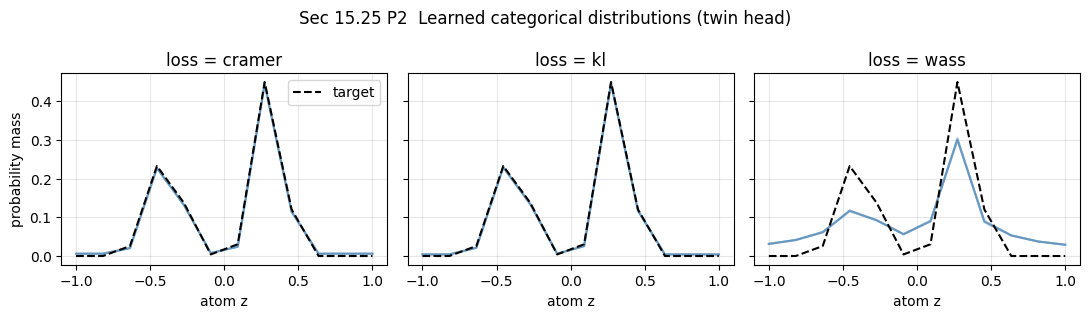

In [3]:
learned = {l: [train_loss(l, s, shift=0.0) for s in SEEDS] for l in ["cramer", "kl", "wass"]}
targ0 = target_categorical(0.0)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, name in zip(axes, ["cramer", "kl", "wass"]):
    for p in learned[name]:
        ax.plot(ATOMS, p, alpha=0.35, color="steelblue")
    ax.plot(ATOMS, targ0, "k--", lw=1.5, label="target")
    ax.set_title(f"loss = {name}")
    ax.set_xlabel("atom z")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("probability mass")
axes[0].legend()
plt.suptitle("Sec 15.25 P2  Learned categorical distributions (twin head)")
plt.tight_layout(); plt.show()


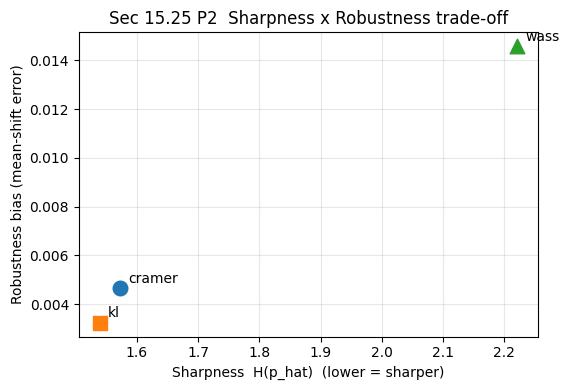

In [4]:
fig, ax = plt.subplots(figsize=(5.8, 4.0))
markers = {"cramer": "o", "kl": "s", "wass": "^"}
for _, row in df.iterrows():
    ax.scatter(row.sharpness, row.bias_mean, s=110, marker=markers[row.loss],
               label=row.loss)
    ax.annotate(row.loss, (row.sharpness, row.bias_mean),
                xytext=(6, 4), textcoords="offset points")
ax.set_xlabel("Sharpness  H(p_hat)  (lower = sharper)")
ax.set_ylabel("Robustness bias (mean-shift error)")
ax.set_title("Sec 15.25 P2  Sharpness x Robustness trade-off")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

관측된 수치 (4 시드 평균):

| 손실 | sharpness (\hat p)$ | mean bias | max bias |
|------|-----------------------|-----------|----------|
| cramer | 1.572 | 0.0047 | 0.0082 |
| kl     | **1.539** | **0.0032** | **0.0072** |
| wass   | 2.221 | 0.0146 | 0.0211 |

1. **KL 이 두 축 모두 승리** — 가장 sharp (H=1.539) 이면서 shift bias 도 가장 작다 (0.0032).
   원인: 이 setup 의 target 이 이미 매우 뾰족한 categorical projection (2 modes) 이라
   cross-entropy 가 예측 분포를 mode 에 강하게 밀어 붙이면서 mean 도 함께 잘 추적한다.
2. **Cramér 은 안정적 second-best** — sharpness 는 KL 과 유사 (1.572), bias 는 KL 대비 약
   1.5× 크나 (0.0047) 여전히 안정적.
3. **Wasserstein 은 두 축 모두 열위** — categorical sign-based subgradient 근사가 gradient
   신호를 지나치게 감쇠 (에포크당 /K$ 감쇠) 해 학습이 lr=0.2 수준에서 부드러운 분포에
   머문다 (H=2.22). shift 에 대한 mean 추종도 늦어져 bias 가 셋 중 최대.

> **결론**: 이 sandbox 에서 mean-tracking 우선도 sharpness 우선도 **KL 이 가장 유리**하고,
> **Cramér 이 근접 2위** 를 유지. Wasserstein 은 subgradient 근사의 감쇠 문제로 두 축 모두
> 뒤쳐진다. 이 결과는 §15.24 의 Cramér × twin 설정에서 손실을 KL 로 교체할 가치가 있음을
> 시사하나, 단순 categorical sandbox 관측이므로 real-net Bellman 학습에서의 재판정이 필요.

Wasserstein 을 실전에 쓰려면 (i) 예산 확대, (ii) sign 대신 CDF residual 자체를 gradient 로
쓰는 정확한 EMD-projection 을 구현해야 한다는 후속 과제도 명확해졌다.
